# Argiope × SegmentR — the whole workflow in R

From **a folder of images** to opisthosoma masks, CIELAB palettes, a paginated gallery and a
per-specimen dashboard, driven entirely from R.

The segmenter is a trained U-Net living in PyTorch. R does not reimplement it: it calls the
pipeline across a process boundary — one model load for the whole folder — and then reads the
run's own artefacts. Compositing and drawing happen in R.

Everything this notebook needs is in this folder except two things that cannot be shipped:
the `argiope` conda environment and the trained checkpoint. See `README.md` for those.

## 1. Check the R side

Three CRAN packages, all binary, no compilation. If any is missing:
`install.packages(c("jsonlite", "jpeg", "png"))` — or run `install_R_packages.R`.

In [1]:
pkgs <- c("jsonlite", "jpeg", "png")
data.frame(package = pkgs,
           installed = vapply(pkgs, requireNamespace, logical(1), quietly = TRUE),
           row.names = NULL)

package,installed
<chr>,<lgl>
jsonlite,TRUE
jpeg,TRUE
png,TRUE


In [2]:
cat(R.version.string, "\n")
cat("working directory:", getwd(), "\n")

R version 4.5.1 (2025-06-13 ucrt) 


working directory: C:/Users/Usuario/Documents/Research_Projects/Argiope/repro/segmentr/notebook 


## 2. Load the workflow and find Python

`argiope_segmentR.R` locates `adapt_unet.py` relative to itself, so no paths need configuring
as long as the repository layout is intact.

Python is resolved in this order: `options(argiope.python=)`, the `ARGIOPE_PYTHON` environment
variable, the interpreter beside the `argiope` executable, then `PATH`. If R was launched from
the activated conda environment, none of that is needed.

In [3]:
source("../R/argiope_segmentR.R")

py <- Sys.getenv("ARGIOPE_PYTHON", unset = "")
if (nzchar(py)) options(argiope.python = py)

argiope_python()   # errors with an actionable message if it cannot be found

[1] "C:/Users/Usuario/miniforge3/envs/argiope/python.exe"

## 3. Run the pipeline over a folder

`argiope_gallery()` shells out once, processes every image in the folder, and returns a
gallery object. Images the U-Net finds nothing in are **not dropped silently** — they are
recorded with a reason.

In [4]:
g <- argiope_gallery(
  dir    = "sample_images",   # any folder of .jpg/.jpeg/.png, searched recursively
  out    = "runs",            # where the run directory is written
  run_id = "demo"
)
g

Running the pipeline over sample_images (one model load) ...



<argiope gallery> C:/Users/Usuario/Documents/Research_Projects/Argiope/repro/segmentr/notebook/runs/demo 
  6 images · 6 with a mask · 0 empty
  median score 0.982 · pages of 6: 1

## 4. Read the table before looking at pictures

One row per image: whether a mask came back, the segmenter's confidence, the mask size, and
the reason when it did not.

In [5]:
it <- argiope_items(g)
it[, c("image", "group", "has_mask", "score", "px")]

image,group,has_mask,score,px
<chr>,<chr>,<lgl>,<dbl>,<int>
argiope_argentata__6ae7af3ae496797c.jpg,sample_images,TRUE,0.9767,29162
argiope_argentata__9898bbadf0ef241f.jpg,sample_images,TRUE,0.9702,17535
argiope_aurantia__131191bffe7c4a47.jpg,sample_images,TRUE,0.9812,31774
argiope_aurantia__ced10dfeb081ce47.jpg,sample_images,TRUE,0.9821,68644
argiope_bruennichi__afedd500df72ae16.jpg,sample_images,TRUE,0.9847,73923
argiope_bruennichi__c6726664e01fb407.jpg,sample_images,TRUE,0.9823,41653


In [6]:
cat("with a mask:", sum(it$has_mask), "of", nrow(it), "\n")
if (any(!it$has_mask)) print(subset(it, !has_mask)[, c("image", "reason")])

with a mask: 6 of 6 


## 5. The palette of one specimen

`coverage` is the fraction of the mask's pixels in that cluster; `lab_*` are the CIELAB
coordinates of the centroid. HEX + Lab + coverage is the "pantone".

In [7]:
first <- it$image[it$has_mask][1]
argiope_palette_of(g, first)

hex,coverage,lab_l,lab_a,lab_b,size
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
#CFC986,0.32656,80.036,-8.111,34.144,9523
#ACA763,0.27615,67.417,-8.014,35.843,8053
#EFECB3,0.22594,92.376,-7.657,27.833,6589
#898537,0.09663,54.391,-9.043,41.578,2818
#A6AB2D,0.07472,67.617,-17.308,60.141,2179


## 6. The gallery as a paginated grid

Each cell: the photograph with the mask outlined in yellow and the background pushed back,
the palette bar proportional to coverage, the leading HEX values, the score and the mask area.

pages of 6: 1 


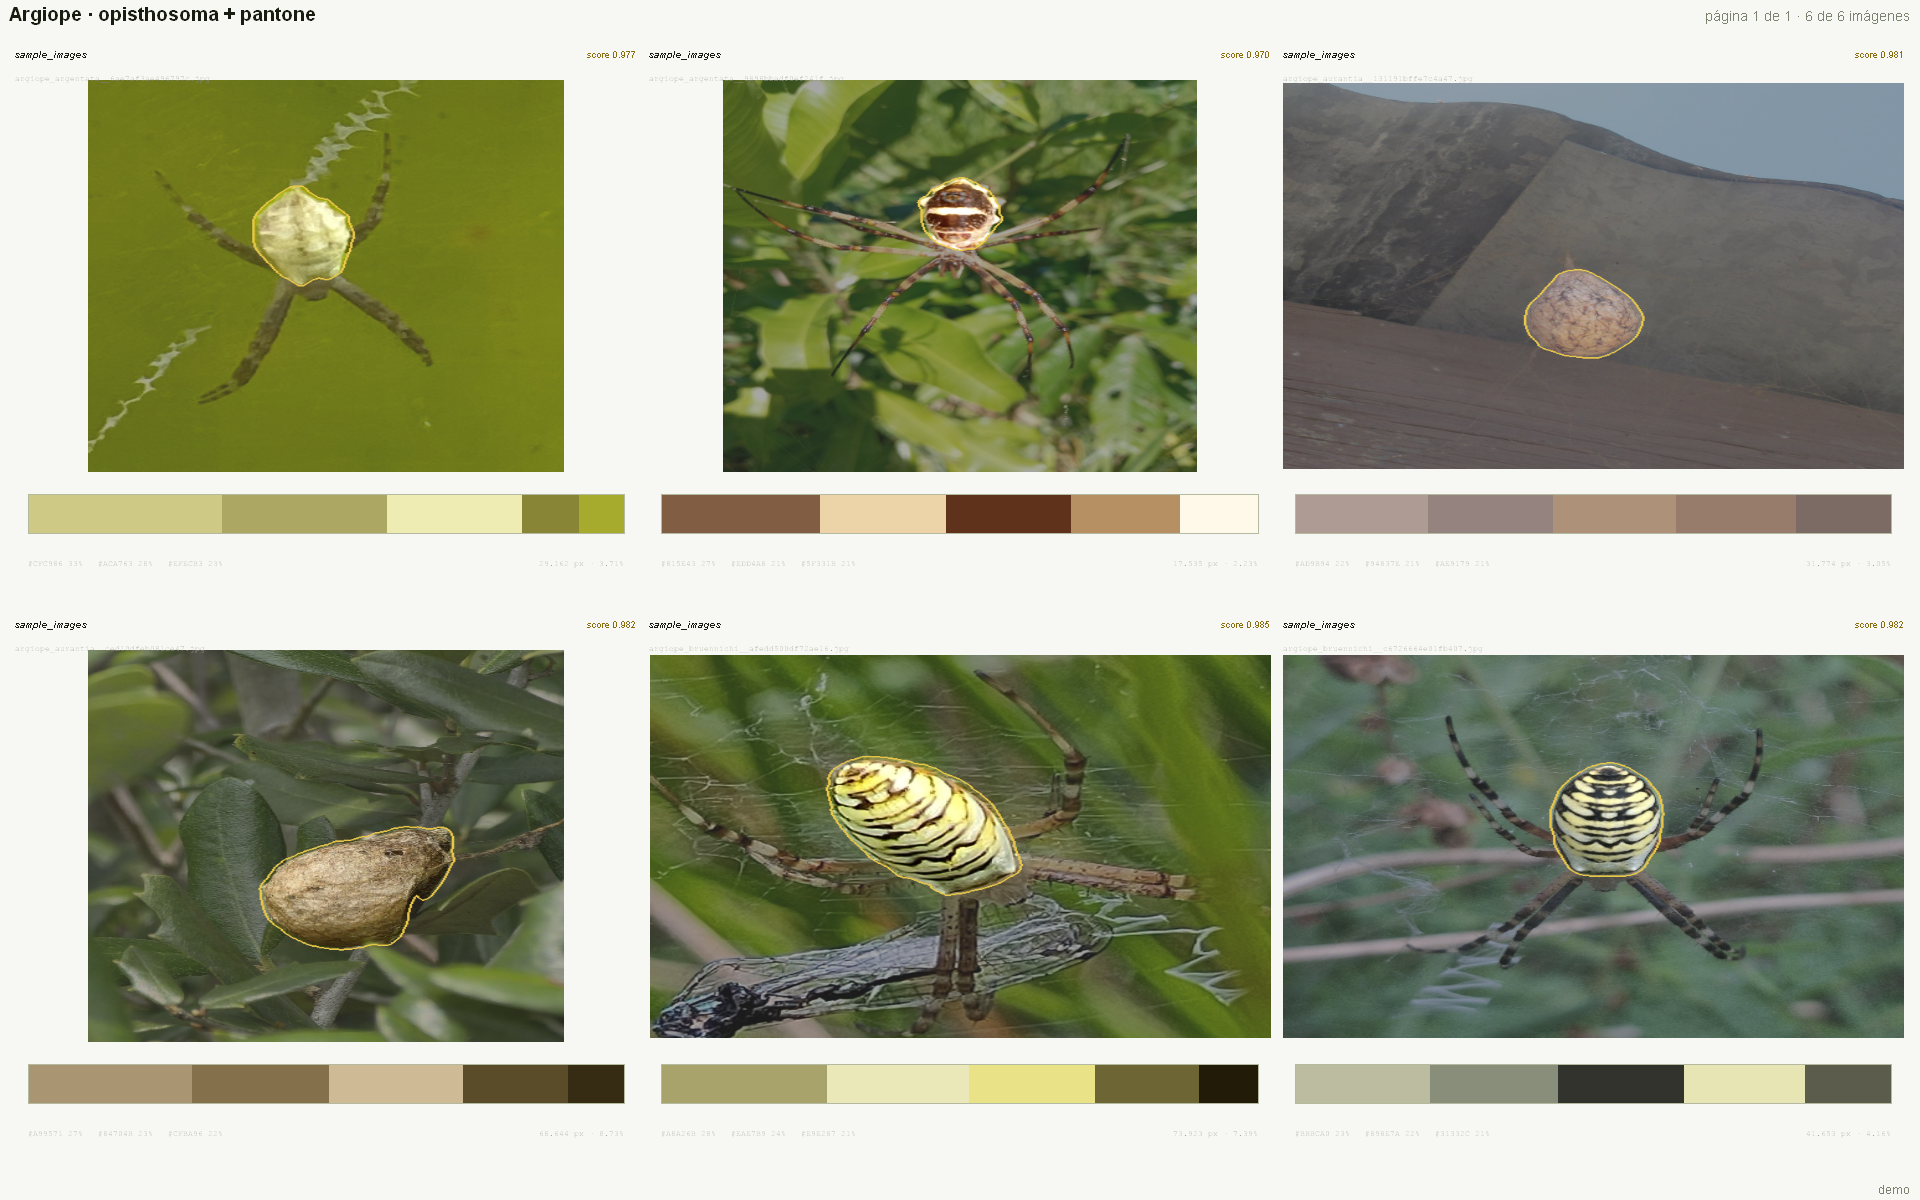

In [8]:
options(repr.plot.width = 16, repr.plot.height = 10)

cat("pages of 6:", argiope_pages(g), "\n")
argiope_plot(g, page = 1)

## 7. Selecting specimens

In an interactive session `argiope_pick(g)` opens a real multi-selection list
(`utils::select.list`); in a script — including this notebook — it returns everything, so
batch use keeps working. You can also select by name or index without any dialog.

[1] "argiope_argentata__6ae7af3ae496797c.jpg"
[2] "argiope_argentata__9898bbadf0ef241f.jpg"
[3] "argiope_aurantia__131191bffe7c4a47.jpg"

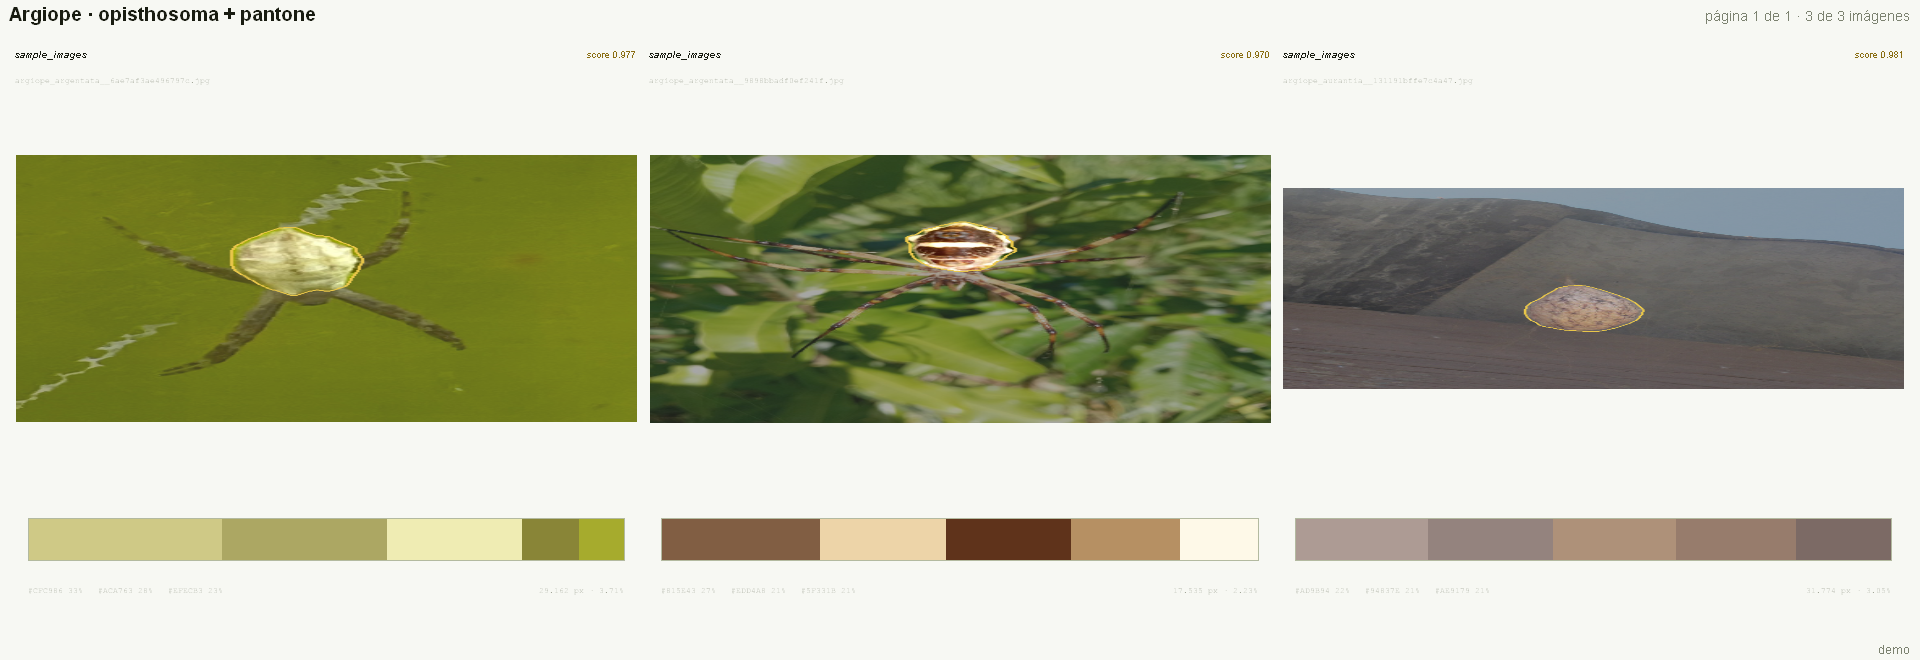

In [9]:
options(repr.plot.width = 16, repr.plot.height = 5.5)

chosen <- it$image[it$has_mask][1:3]
chosen
argiope_plot(g, select = chosen, per_page = 3)

## 8. The dashboard for one specimen

Four panels: the photograph with the detection box and mask contour; the dominant colours
with HEX, coverage and Lab; the RGB histogram of the masked pixels; and the mask recoloured
by assigning every pixel to its nearest centroid.

The recolouring reproduces the pipeline's own rule rather than approximating it — masked
pixels go to CIELAB through `grDevices::convertColor`, base R, and take the nearest centroid.

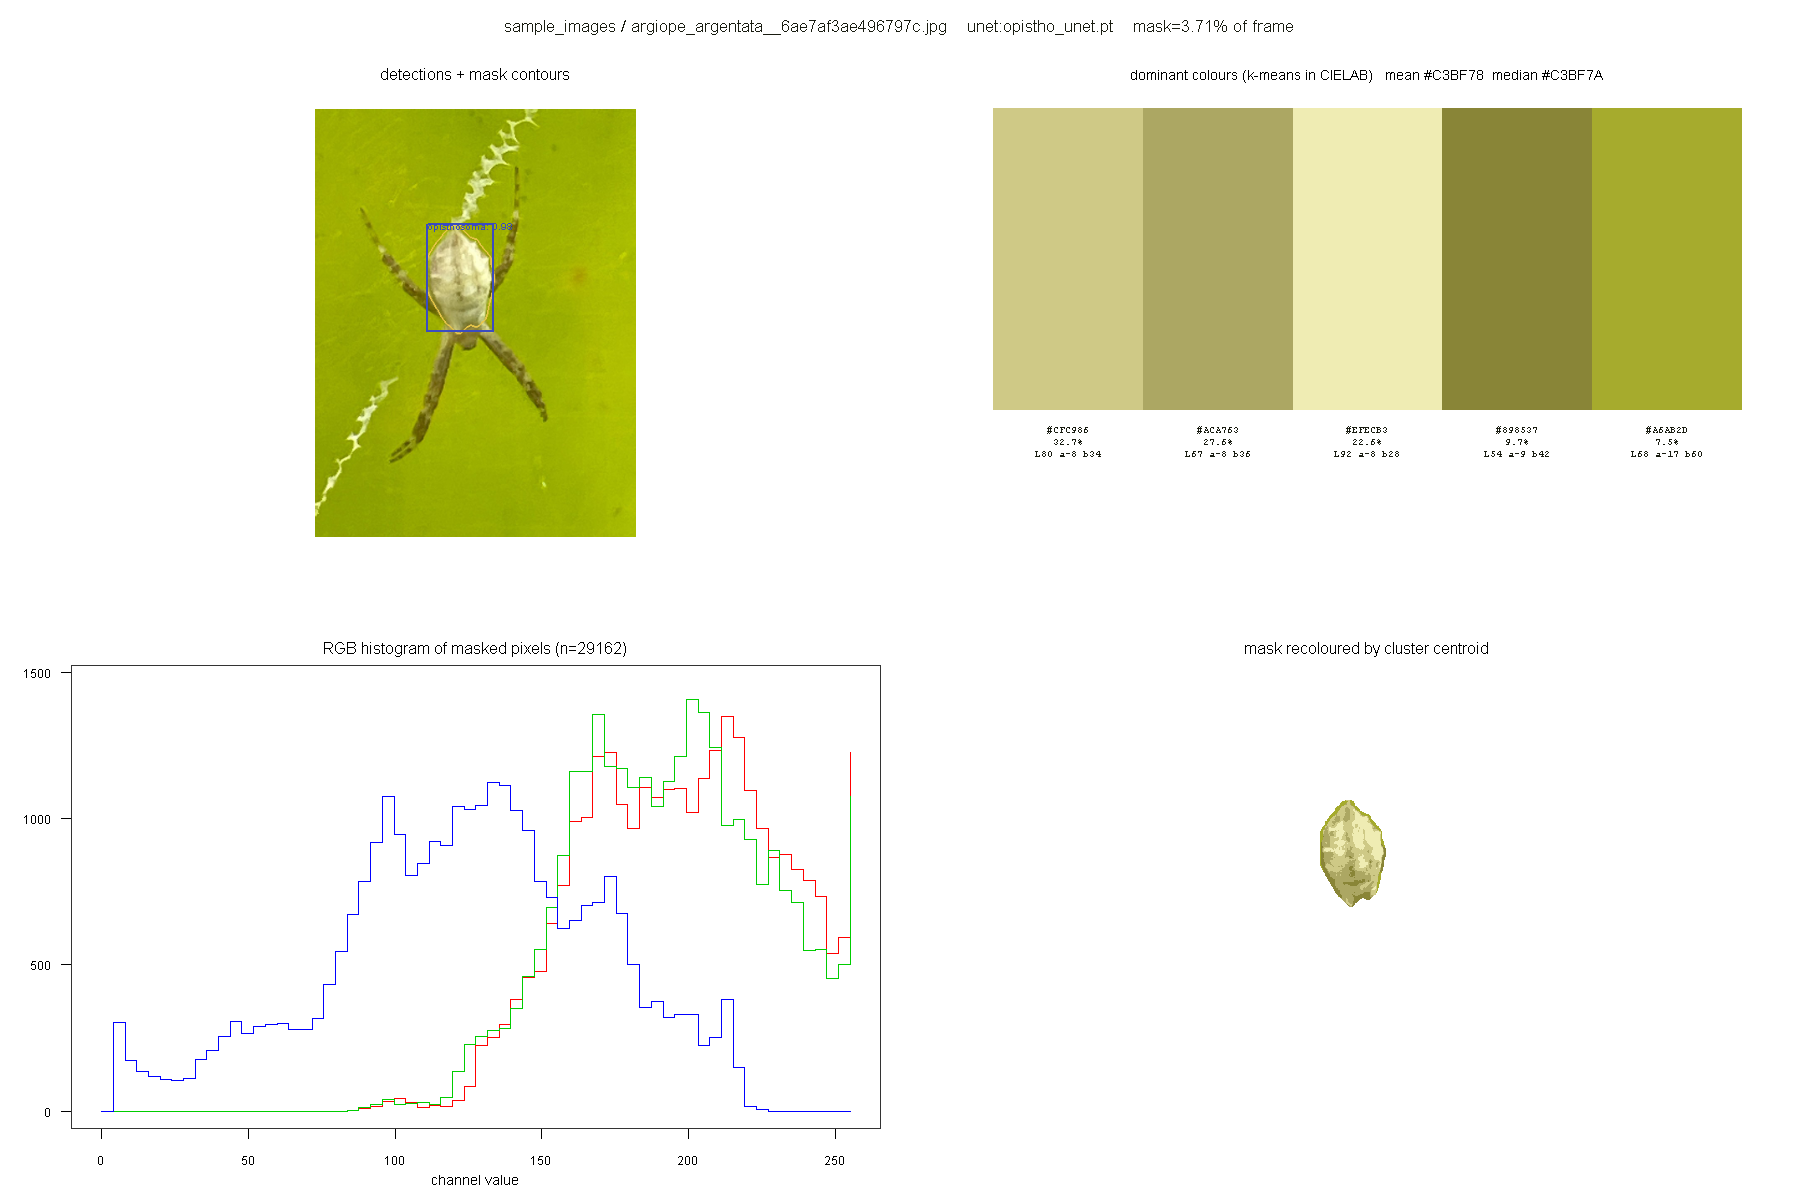

In [10]:
options(repr.plot.width = 15, repr.plot.height = 10)

res <- argiope_dashboard(g, first)

In [11]:
str(res[c("image", "mask_px", "mask_frac", "mean_color", "median_color")])
res$cluster_sizes

List of 5
 $ image       : chr "argiope_argentata__6ae7af3ae496797c.jpg"
 $ mask_px     : int 29162
 $ mask_frac   : num 0.0371
 $ mean_color  : chr "#C3BF78"
 $ median_color: chr "#C3BF7A"


[1] 9539 8060 6598 2817 2148

## 9. Export

Every page into one PDF, or just a selection. Rasters are embedded uncompressed, so lower
`maxdim` for a large gallery.

In [12]:
argiope_pdf(g, "demo_gallery.pdf", per_page = 6)
file.exists("demo_gallery.pdf")

Wrote 1 page(s) -> C:/Users/Usuario/Documents/Research_Projects/Argiope/repro/segmentr/notebook/demo_gallery.pdf



[1] TRUE

## 10. What landed on disk

A run is reproducible from `run_config.json` alone. Colour can be recomputed from the
artefacts without loading the model at all:

```bash
python ../adapt_unet.py --from-json runs/demo
```

In [13]:
files <- list.files("runs/demo", recursive = TRUE)
cat(length(files), "files\n")
head(files, 20)

16 files


[1] "colors.csv"                                                            
 [2] "json/masks/sample_images__argiope_argentata__6ae7af3ae496797c_000.png" 
 [3] "json/masks/sample_images__argiope_argentata__9898bbadf0ef241f_000.png" 
 [4] "json/masks/sample_images__argiope_aurantia__131191bffe7c4a47_000.png"  
 [5] "json/masks/sample_images__argiope_aurantia__ced10dfeb081ce47_000.png"  
 [6] "json/masks/sample_images__argiope_bruennichi__afedd500df72ae16_000.png"
 [7] "json/masks/sample_images__argiope_bruennichi__c6726664e01fb407_000.png"
 [8] "json/sample_images__argiope_argentata__6ae7af3ae496797c.json"          
 [9] "json/sample_images__argiope_argentata__9898bbadf0ef241f.json"          
[10] "json/sample_images__argiope_aurantia__131191bffe7c4a47.json"           
[11] "json/sample_images__argiope_aurantia__ced10dfeb081ce47.json"           
[12] "json/sample_images__argiope_bruennichi__afedd500df72ae16.json"         
[13] "json/sample_images__argiope_bruennichi__c6726664e01fb407.json"         
[14] "run_config.json"                                                       
[15] "skipped.csv"                                                           
[16] "summary.json"

## Notes and limits

- **No ground truth here.** These images are not annotated, so nothing in this notebook is an
  accuracy measurement. It shows what the pipeline *produces*. The measured figure, on the
  held-out annotated split, is a median IoU of 0.765, with the colour taken from the predicted
  mask indistinguishable from the colour taken from the hand-drawn one (ΔE 1.51) wherever
  IoU ≥ 0.7.
- **A mask is not automatically correct.** On a 100-image unseen sample, 81 produced a mask
  and 3 of those were fragments under 0.1% of the frame — all three scoring below 0.70 against
  a median of 0.959, so a score filter separates them.
- **Point it anywhere.** Replace `"sample_images"` with any folder; add `n =` to take a seeded
  random sample of it.
- The colour, artefact and QA stages are a port of **SegmentR** (Boyko 2025, MIT); the
  segmenter is ours. Colours are reported as HEX, Lab coordinates and coverage — no PANTONE®
  compatibility is claimed.